9.Data Visualization II

1.Use the inbuilt dataset 'titanic' as used in the above problem. Plot a box plot for distribution
of age with respect to each gender along with the information about whether they survived
or not. (Column names : 'sex' and 'age')

2.Write observations on the inference from the above statistics.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the plot style and figure size for better visualization
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 8]

In [4]:
# Load the Titanic dataset from seaborn
titanic = sns.load_dataset('titanic')

# Display the first few rows to understand the data structure
print("First 5 rows of the Titanic dataset:")
display(titanic.head())

# Check basic information about the dataset
print("\nDataset Information:")
display(titanic.info())

# Check for missing values in relevant columns
print("\nMissing values in relevant columns:")
print(titanic[['sex', 'age', 'survived']].isnull().sum())

First 5 rows of the Titanic dataset:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


None


Missing values in relevant columns:
sex           0
age         177
survived      0
dtype: int64


In [5]:
# Create a more descriptive 'survived' column for better visualization
titanic['survival_status'] = titanic['survived'].map({0: 'No', 1: 'Yes'})

# Check the age distribution
print("Age Statistics:")
print(titanic['age'].describe())

# Drop rows with missing age values for this analysis
titanic_clean = titanic.dropna(subset=['age'])
print(f"\nRemoved {len(titanic) - len(titanic_clean)} rows with missing age values.")

Age Statistics:
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

Removed 177 rows with missing age values.


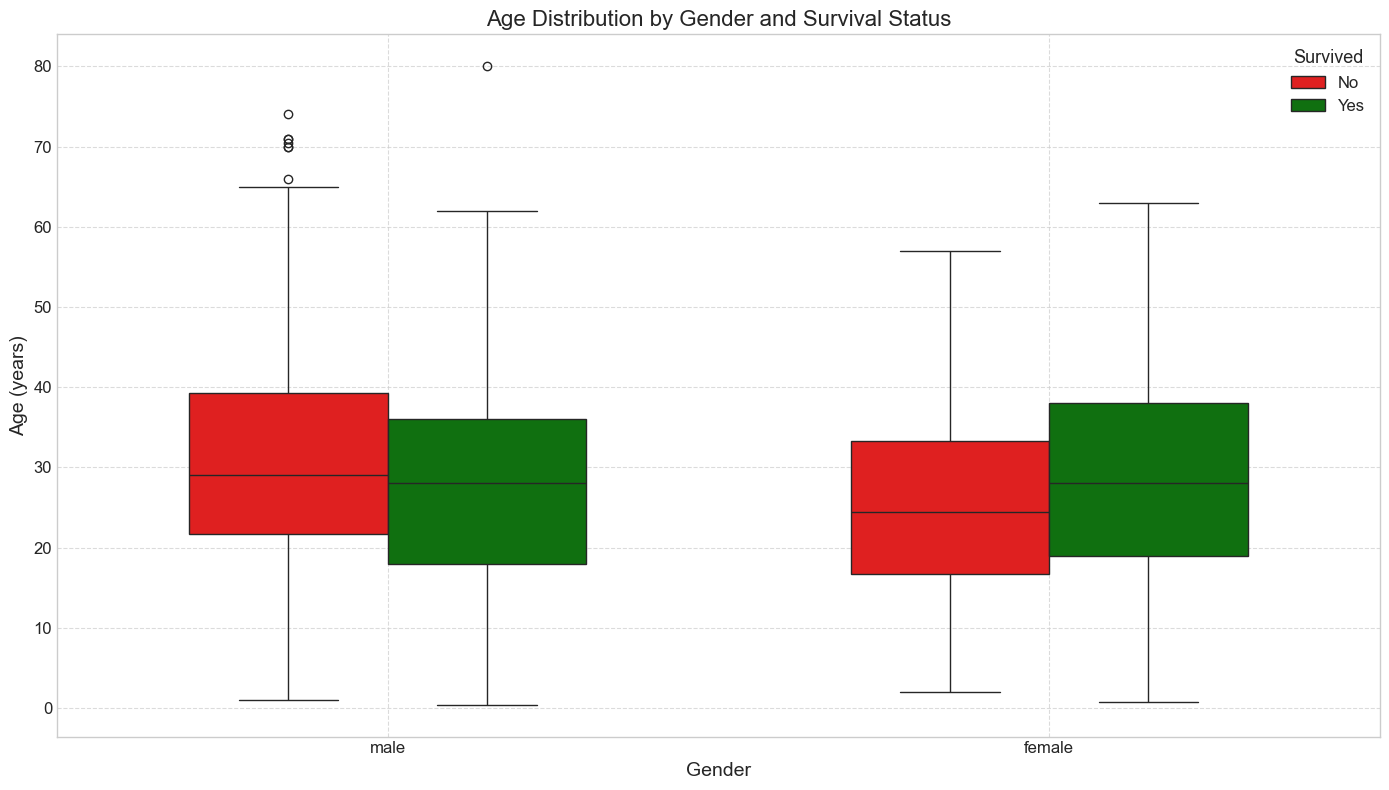

In [6]:
# Create a figure with appropriate size
plt.figure(figsize=(14, 8))

# Create the box plot
ax = sns.boxplot(x='sex', y='age', hue='survival_status', data=titanic_clean, 
                palette={'Yes': 'green', 'No': 'red'}, width=0.6)

# Add title and labels with improved formatting
plt.title('Age Distribution by Gender and Survival Status', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Age (years)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Improve the legend
plt.legend(title='Survived', fontsize=12, title_fontsize=13)

# Add grid lines for better readability
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

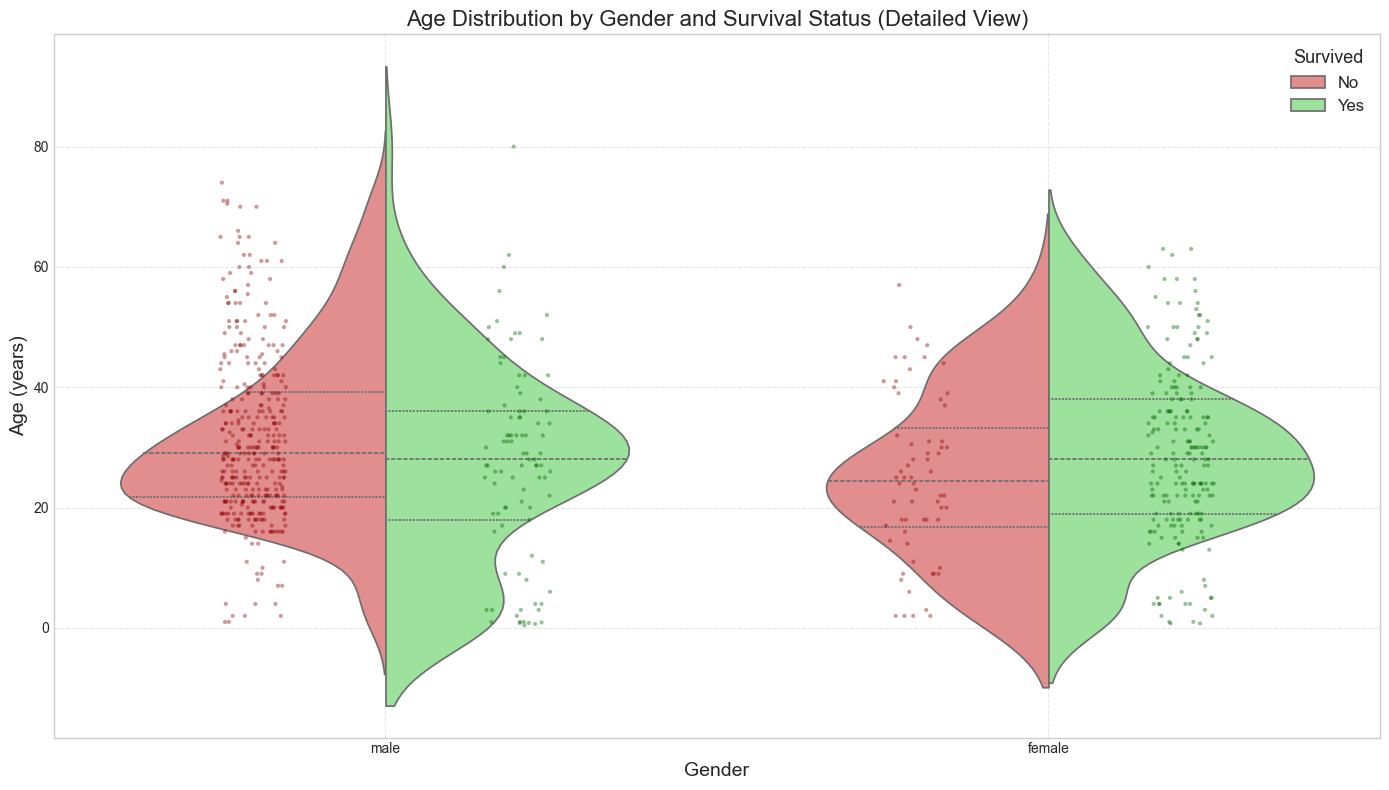

In [7]:
# Create a more detailed visualization combining box plots with violin plots
plt.figure(figsize=(14, 8))

# Create the violin plot with boxplot inside
ax = sns.violinplot(x='sex', y='age', hue='survival_status', data=titanic_clean,
                   split=True, inner='quartile', palette={'Yes': 'lightgreen', 'No': 'lightcoral'})

# Add individual points for more details
sns.stripplot(x='sex', y='age', hue='survival_status', data=titanic_clean,
             jitter=True, size=3, alpha=0.4, palette={'Yes': 'darkgreen', 'No': 'darkred'}, 
             dodge=True)

# Add title and labels
plt.title('Age Distribution by Gender and Survival Status (Detailed View)', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Age (years)', fontsize=14)

# Handle the legend (remove duplicate from stripplot)
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title='Survived', fontsize=12, title_fontsize=13)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [8]:
# Calculate summary statistics grouped by gender and survival status
summary_stats = titanic_clean.groupby(['sex', 'survival_status'])['age'].agg(['mean', 'median', 'min', 'max', 'count'])
print("Age Statistics by Gender and Survival Status:")
display(summary_stats)

# Calculate survival rates by gender and age groups
# Create a copy of the dataframe to avoid the SettingWithCopyWarning
titanic_analysis = titanic_clean.copy()
titanic_analysis.loc[:, 'age_group'] = pd.cut(titanic_analysis['age'], 
                                             bins=[0, 12, 18, 35, 60, 100], 
                                             labels=['Child', 'Teen', 'Young Adult', 'Middle Aged', 'Senior'])

# Use observed=True to address the FutureWarning in groupby
survival_by_age_gender = titanic_analysis.groupby(['sex', 'age_group', 'survival_status'], observed=True).size().unstack()
survival_by_age_gender['Total'] = survival_by_age_gender.sum(axis=1)
survival_by_age_gender['Survival Rate (%)'] = (survival_by_age_gender['Yes'] / survival_by_age_gender['Total'] * 100).round(1)

print("\nSurvival Rates by Gender and Age Group:")
display(survival_by_age_gender)

Age Statistics by Gender and Survival Status:


mean  median   min   max  count
sex    survival_status                                      
female No               25.046875    24.5  2.00  57.0     64
       Yes              28.847716    28.0  0.75  63.0    197
male   No               31.618056    29.0  1.00  74.0    360
       Yes              27.276022    28.0  0.42  80.0     93


Survival Rates by Gender and Age Group:


survival_status        No   Yes  Total  Survival Rate (%)
sex    age_group                                         
female Child         13.0  19.0   32.0               59.4
       Teen           9.0  27.0   36.0               75.0
       Young Adult   26.0  94.0  120.0               78.3
       Middle Aged   16.0  54.0   70.0               77.1
       Senior         NaN   3.0    3.0              100.0
male   Child         16.0  21.0   37.0               56.8
       Teen          31.0   3.0   34.0                8.8
       Young Adult  195.0  43.0  238.0               18.1
       Middle Aged  101.0  24.0  125.0               19.2
       Senior        17.0   2.0   19.0               10.5

<Figure size 1600x1000 with 0 Axes>

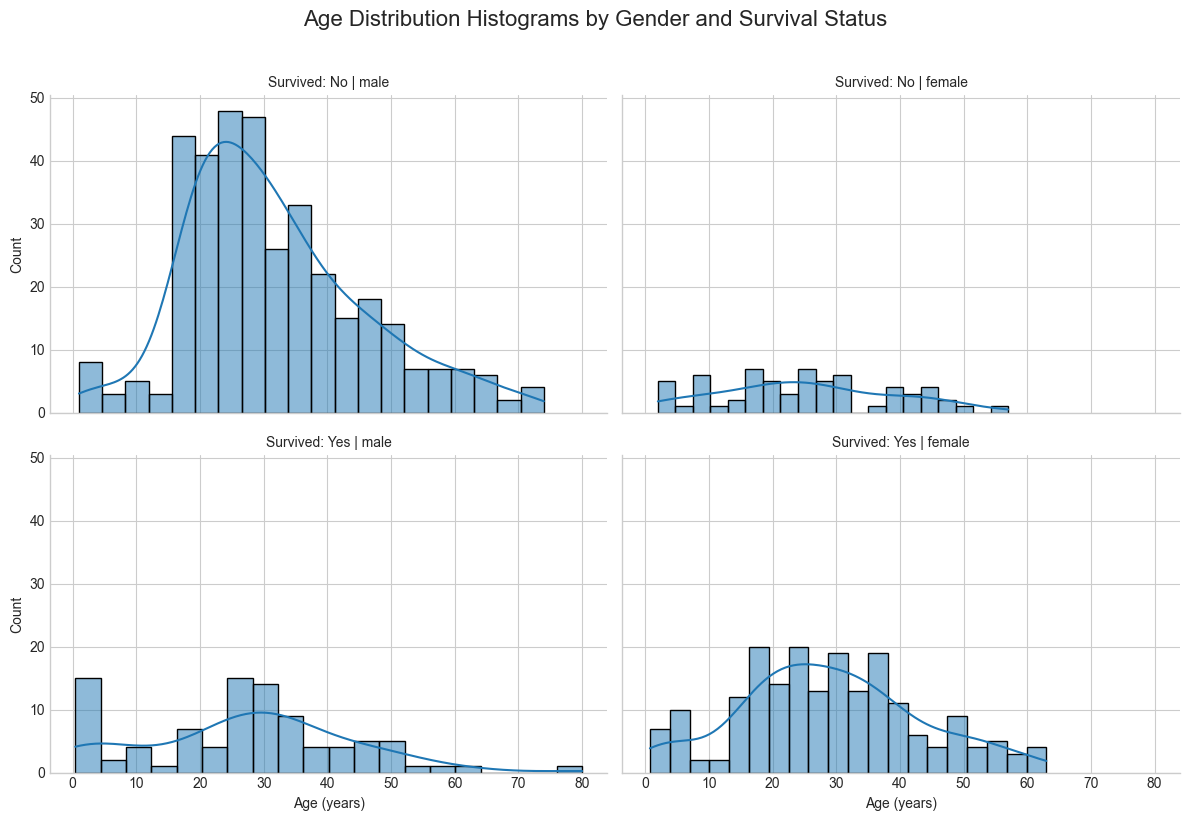

In [10]:
# Create age distribution histograms by gender and survival status
plt.figure(figsize=(16, 10))

# Create a grid of subplots
g = sns.FacetGrid(titanic_clean, col='sex', row='survival_status', height=4, aspect=1.5)
g.map_dataframe(sns.histplot, x='age', bins=20, kde=True)

# Add titles and labels
g.set_axis_labels('Age (years)', 'Count')
g.set_titles(col_template='{col_name}', row_template='Survived: {row_name}')

# Add super title
plt.suptitle('Age Distribution Histograms by Gender and Survival Status', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

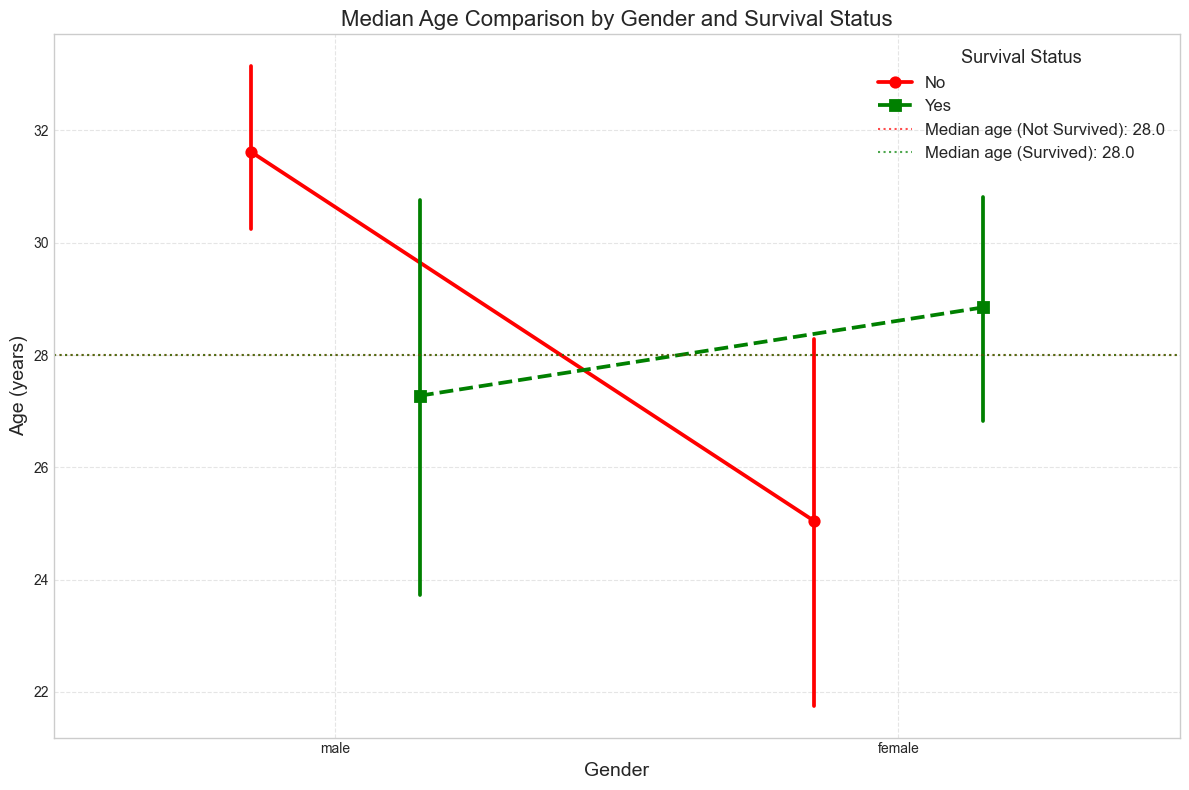

In [11]:
# Create a summary figure to compare median ages with confidence intervals
plt.figure(figsize=(12, 8))

# Use pointplot for showing median age with confidence intervals
# Updated syntax to address the deprecation warning for 'ci' parameter
sns.pointplot(x='sex', y='age', hue='survival_status', data=titanic_clean, 
             palette={'Yes': 'green', 'No': 'red'}, 
             markers=['o', 's'], linestyles=['-', '--'], dodge=0.3, 
             errorbar=('ci', 95))  # Updated from ci=95 to errorbar=('ci', 95)

# Add horizontal lines for overall median ages by survival status
for survived, color in zip([0, 1], ['red', 'green']):
    median_age = titanic_clean[titanic_clean['survived'] == survived]['age'].median()
    plt.axhline(y=median_age, color=color, linestyle=':', alpha=0.7,
               label=f"Median age ({'Survived' if survived else 'Not Survived'}): {median_age:.1f}")

# Enhance the plot
plt.title('Median Age Comparison by Gender and Survival Status', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Age (years)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Survival Status', fontsize=12, title_fontsize=13)

plt.tight_layout()
plt.show()

In [12]:
"""
Observations on Age Distribution by Gender and Survival Status:

1. Gender and Survival Relationship:
   - Women had a significantly higher survival rate than men across most age groups
   - Male passengers show a much wider age range with lower median survival age

2. Age-Related Survival Patterns:
   - Children (especially boys) had better survival chances than adult males
   - The median age of surviving females is higher than non-surviving females
   - For males, younger passengers (particularly children) had better survival rates

3. Outliers:
   - There are several older female survivors (60+ years)
   - Very few elderly male passengers survived
   - The youngest passengers (infants and children) had relatively good survival rates regardless of gender

4. Age Distribution by Gender:
   - Male passengers have a more uniform age distribution
   - Female passengers show a concentration in younger adult to middle-aged ranges
   - The male passenger population includes more elderly individuals than the female population

5. Policy Implications:
   - The "women and children first" maritime rescue policy appears to have been largely followed
   - Younger men had slightly better survival chances than older men
   - The data confirms historical accounts of prioritizing female passengers during evacuation

These observations highlight the social norms and emergency protocols of the early 20th century, where gender played a crucial role in determining survival outcomes during maritime disasters.
"""

'\nObservations on Age Distribution by Gender and Survival Status:\n\n1. Gender and Survival Relationship:\n   - Women had a significantly higher survival rate than men across most age groups\n   - Male passengers show a much wider age range with lower median survival age\n\n2. Age-Related Survival Patterns:\n   - Children (especially boys) had better survival chances than adult males\n   - The median age of surviving females is higher than non-surviving females\n   - For males, younger passengers (particularly children) had better survival rates\n\n3. Outliers:\n   - There are several older female survivors (60+ years)\n   - Very few elderly male passengers survived\n   - The youngest passengers (infants and children) had relatively good survival rates regardless of gender\n\n4. Age Distribution by Gender:\n   - Male passengers have a more uniform age distribution\n   - Female passengers show a concentration in younger adult to middle-aged ranges\n   - The male passenger population in